In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('Gender.csv', sep=',')

In [3]:
df

,Country,Human_development,GII,Rank,Maternal_mortality,Adolescent_birth_rate,Seats_parliament,F_secondary_educ,M_secondary_educ,F_Labour_force,M_Labour_force
0,Switzerland,Very high,0.018,3.0,5.0,2.2,39.8,96.9,97.5,61.7,72.7
1,Norway,Very high,0.016,2.0,2.0,2.3,45.0,99.1,99.3,60.3,72.0
2,Iceland,Very high,0.043,8.0,4.0,5.4,47.6,99.8,99.7,61.7,70.5
3,Hong Kong,Very high,NaN,NaN,NaN,1.6,NaN,77.1,83.4,53.5,65.8
4,Australia,Very high,0.073,19.0,6.0,8.1,37.9,94.6,94.4,61.1,70.5
...,...,...,...,...,...,...,...,...,...,...,...
190,South Sudan,Low,0.587,150.0,1150.0,99.2,32.3,26.5,36.4,70.4,73.6
191,North Korea,NaN,NaN,NaN,89.0,2.3,17.6,NaN,NaN,77.2,86.1
192,Monaco,NaN,NaN,NaN,NaN,7.2,33.3,NaN,NaN,NaN,NaN
193,Nauru,NaN,NaN,NaN,NaN,72.5,10.5,NaN,NaN,NaN,NaN


In [4]:
print(df.isna().sum())

Country                   0
Human_development         4
GII                      25
Rank                     25
Maternal_mortality       11
Adolescent_birth_rate     0
Seats_parliament          2
F_secondary_educ         18
M_secondary_educ         18
F_Labour_force           15
M_Labour_force           15
dtype: int64


In [5]:
df_clean = df.dropna()

In [6]:
df_clean

,Country,Human_development,GII,Rank,Maternal_mortality,Adolescent_birth_rate,Seats_parliament,F_secondary_educ,M_secondary_educ,F_Labour_force,M_Labour_force
0,Switzerland,Very high,0.018,3.0,5.0,2.2,39.8,96.9,97.5,61.7,72.7
1,Norway,Very high,0.016,2.0,2.0,2.3,45.0,99.1,99.3,60.3,72.0
2,Iceland,Very high,0.043,8.0,4.0,5.4,47.6,99.8,99.7,61.7,70.5
4,Australia,Very high,0.073,19.0,6.0,8.1,37.9,94.6,94.4,61.1,70.5
5,Denmark,Very high,0.013,1.0,4.0,1.9,39.7,95.1,95.2,57.7,66.7
...,...,...,...,...,...,...,...,...,...,...,...
186,Burundi,Low,0.505,127.0,548.0,53.6,38.9,7.8,13.0,79.0,77.4
187,Central African Republic,Low,0.672,166.0,829.0,160.5,12.9,13.9,31.6,63.3,79.5
188,Niger,Low,0.611,153.0,509.0,170.5,25.9,9.2,15.2,61.7,84.3
189,Chad,Low,0.652,165.0,1140.0,138.3,32.3,7.7,24.4,46.9,69.9


In [7]:
print(df_clean.isna().sum())

Country                  0
Human_development        0
GII                      0
Rank                     0
Maternal_mortality       0
Adolescent_birth_rate    0
Seats_parliament         0
F_secondary_educ         0
M_secondary_educ         0
F_Labour_force           0
M_Labour_force           0
dtype: int64


Jumlah Negara per tingkat Human Development: 
Human_development
Very high    62
High         42
Medium       36
Low          30
Name: count, dtype: int64




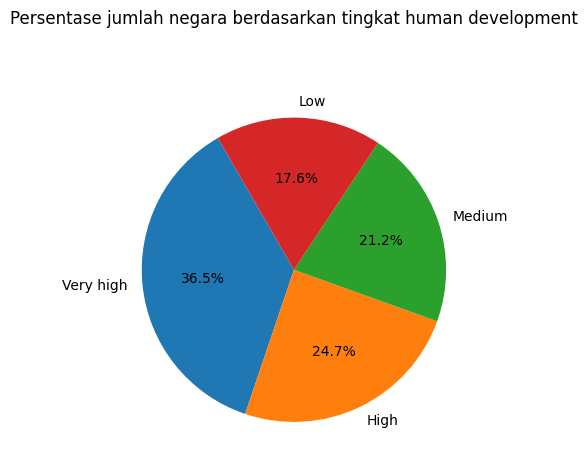

In [8]:
jumlah_negara = df_clean['Human_development'].value_counts()

print("Jumlah Negara per tingkat Human Development: ")
print(jumlah_negara)
print("\n")

jumlah_negara.plot(kind='pie', autopct='%1.1f%%', startangle=120)

plt.title("Persentase jumlah negara berdasarkan tingkat human development", fontsize = 12, pad = 40)

plt.ylabel('')
plt.savefig('Laporan_Visualisasi_Jumlahnegara_HiRes.png', dpi=300, bbox_inches='tight')
plt.tight_layout()

Rata-rata GII Global: 0.344
Median Maternal Mortality Global: 53.0

Negara yang memenuhi kriteria:
                 Country    GII  Maternal_mortality
109              Jamaica  0.335                80.0
103                Libya  0.259                72.0
54               Bahamas  0.329                70.0
56   Trinidad and Tobago  0.344                67.0




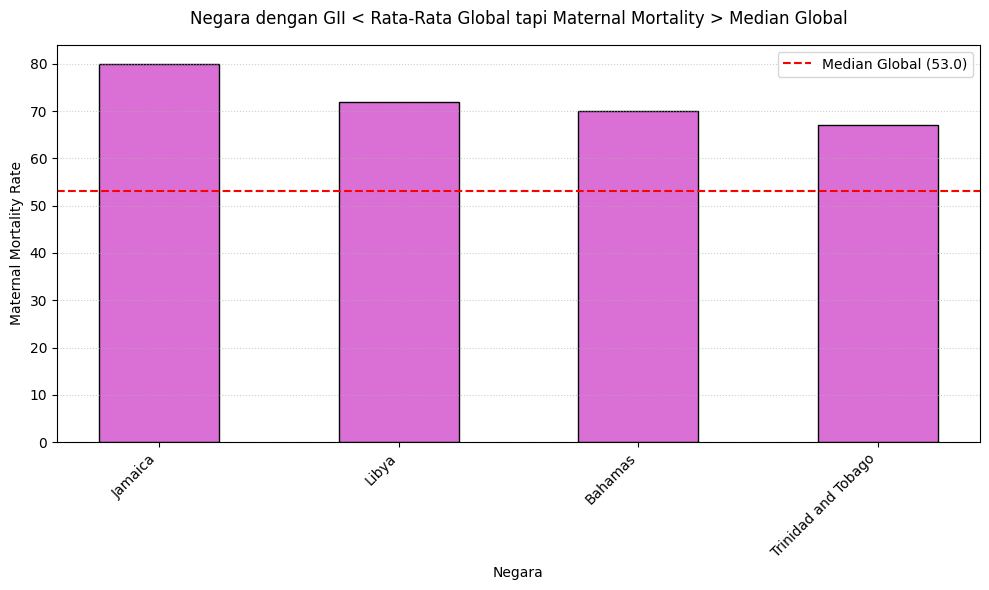

In [9]:
import matplotlib.pyplot as plt

rata_gii_global = df['GII'].mean()
median_maternal_global = df['Maternal_mortality'].get('median') or df['Maternal_mortality'].median()

print(f"Rata-rata GII Global: {rata_gii_global:.3f}")
print(f"Median Maternal Mortality Global: {median_maternal_global}\n")

kondisi = (df['GII'] < rata_gii_global) & (df['Maternal_mortality'] > median_maternal_global)
negara_terpilih = df[kondisi]

negara_terpilih = negara_terpilih.sort_values(by='Maternal_mortality', ascending=False)

print("Negara yang memenuhi kriteria:")
print(negara_terpilih[['Country', 'GII', 'Maternal_mortality']])
print("\n")

if not negara_terpilih.empty:
    plt.figure(figsize=(10, 6))

    plt.bar(
        negara_terpilih['Country'],
        negara_terpilih['Maternal_mortality'],
        color='orchid',
        edgecolor='black',
        width=0.5
    )

    plt.axhline(y=median_maternal_global, color='red', linestyle='--', linewidth=1.5,
                label=f'Median Global ({median_maternal_global})')

    plt.title('Negara dengan GII < Rata-Rata Global tapi Maternal Mortality > Median Global', fontsize=12, pad=15)
    plt.xlabel('Negara', fontsize=10)
    plt.ylabel('Maternal Mortality Rate', fontsize=10)

    plt.xticks(rotation=45, ha='right')

    plt.legend()
    plt.grid(axis='y', linestyle=':', alpha=0.6)
    plt.savefig('Laporan_Visualisasi_GII_NegaraGII.png', dpi=300, bbox_inches='tight')
    plt.tight_layout()
else:
    print("Tidak ada negara yang memenuhi kedua kriteria tersebut secara bersamaan.")

/tmp/ipykernel_1192/708661353.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_clean['Labour_Ratio'] = df_clean['F_Labour_force'] / df_clean['M_Labour_force']


5 Data Teratas Dari df_clean (Bebas NaN):
       Country  F_Labour_force  M_Labour_force  Labour_Ratio  Rank
0  Switzerland            61.7            72.7      0.848693   3.0
1       Norway            60.3            72.0      0.837500   2.0
2      Iceland            61.7            70.5      0.875177   8.0
4    Australia            61.1            70.5      0.866667  19.0
5      Denmark            57.7            66.7      0.865067   1.0




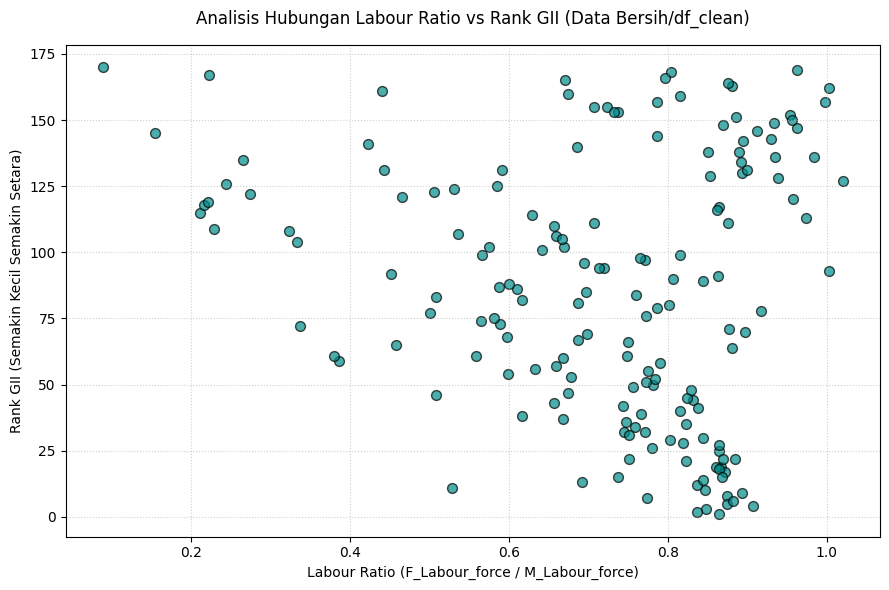

In [10]:
df_clean['Labour_Ratio'] = df_clean['F_Labour_force'] / df_clean['M_Labour_force']

print("5 Data Teratas Dari df_clean (Bebas NaN):")
print(df_clean[['Country', 'F_Labour_force', 'M_Labour_force', 'Labour_Ratio', 'Rank']].head())
print("\n")

plt.figure(figsize=(9, 6))

plt.scatter(
    df_clean['Labour_Ratio'],
    df_clean['Rank'],
    color='darkcyan',
    alpha=0.7,
    edgecolors='black',
    s=50
)


plt.title('Analisis Hubungan Labour Ratio vs Rank GII (Data Bersih/df_clean)', fontsize=12, pad=15)
plt.xlabel('Labour Ratio (F_Labour_force / M_Labour_force)', fontsize=10)
plt.ylabel('Rank GII (Semakin Kecil Semakin Setara)', fontsize=10)

plt.grid(True, linestyle=':', alpha=0.6)
plt.savefig('Laporan_Visualisasi_LR_HiRes.png', dpi=300, bbox_inches='tight')
plt.tight_layout()

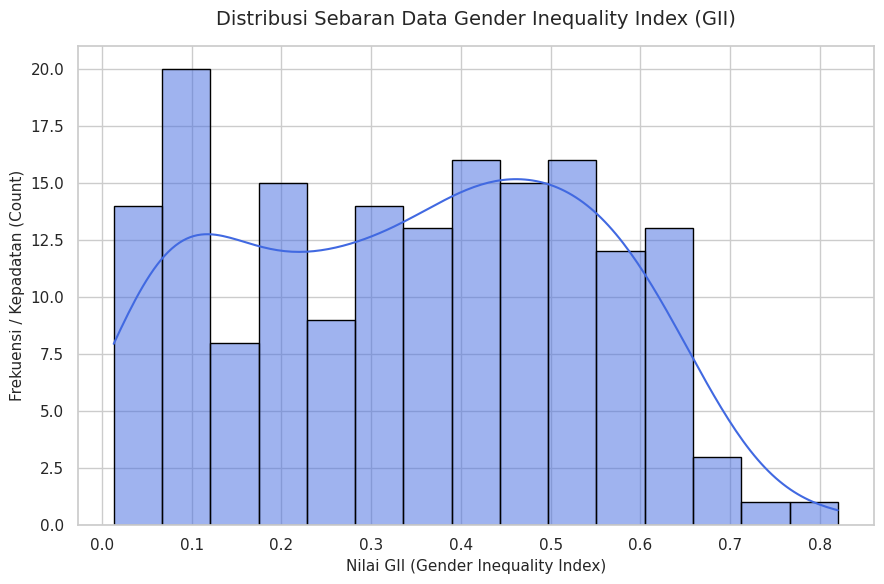

In [11]:
sns.set_theme(style="whitegrid")

plt.figure(figsize=(9, 6))

sns.histplot(
    data=df_clean,
    x='GII',
    kde=True,
    color='royalblue',
    bins=15,
    edgecolor='black'
)


plt.title('Distribusi Sebaran Data Gender Inequality Index (GII)', fontsize=14, pad=15)
plt.xlabel('Nilai GII (Gender Inequality Index)', fontsize=11)
plt.ylabel('Frekuensi / Kepadatan (Count)', fontsize=11)
plt.savefig('Laporan_Visualisasi_sebrandata_HiRes.png', dpi=300, bbox_inches='tight')
plt.tight_layout()

/tmp/ipykernel_1192/4093147711.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_clean['Labour_Ratio'] = df_clean['F_Labour_force'] / df_clean['M_Labour_force']


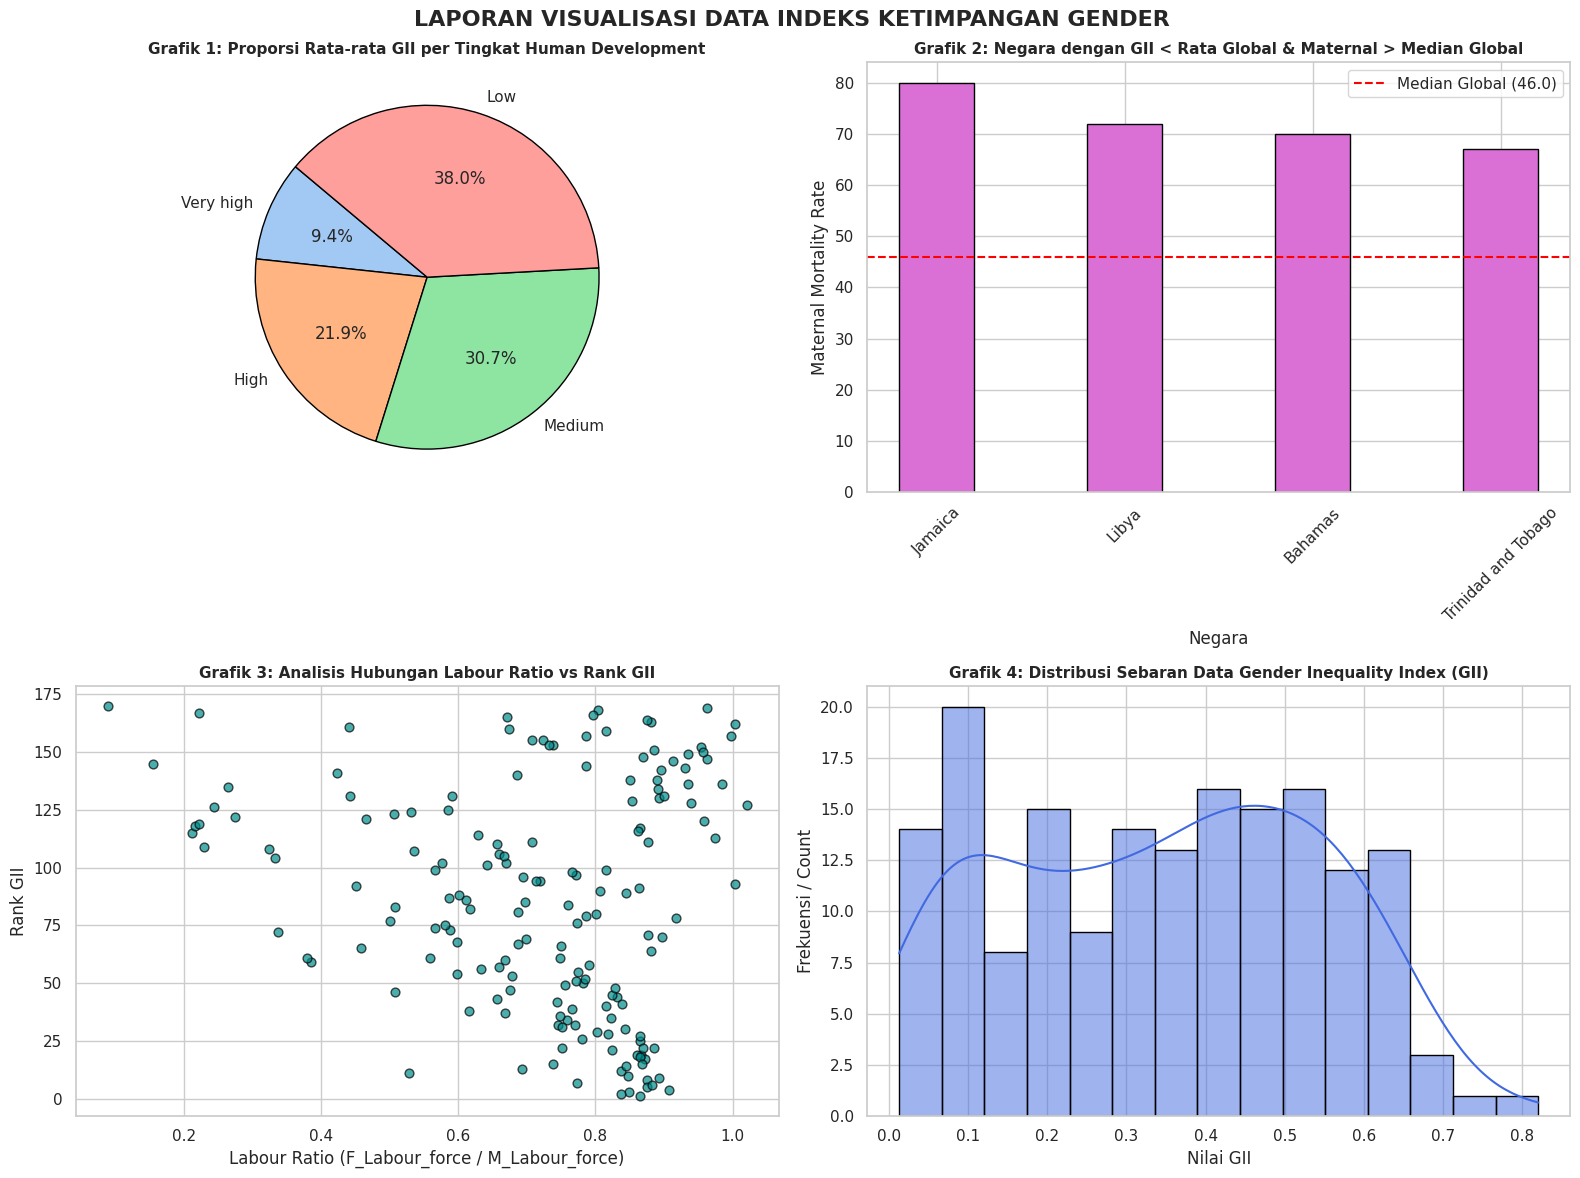

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Persiapan Data (Tetap sama seperti kode Anda)
gii_rata_rata = df_clean.groupby('Human_development')['GII'].mean().sort_values()

rata_gii_global = df_clean['GII'].mean()
median_maternal_global = df_clean['Maternal_mortality'].median()
kondisi = (df_clean['GII'] < rata_gii_global) & (df_clean['Maternal_mortality'] > median_maternal_global)
negara_terpilih = df_clean[kondisi].sort_values(by='Maternal_mortality', ascending=False)

df_clean['Labour_Ratio'] = df_clean['F_Labour_force'] / df_clean['M_Labour_force']

# 2. Membuat Canvas Subplots
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
sns.set_theme(style="whitegrid")

# --- GRAFIK 1: DIUBAH MENJADI PIE CHART ---
# Menggunakan warna pastel agar terlihat rapi dan bersih
colors = sns.color_palette('pastel')[0:len(gii_rata_rata)]
axes[0, 0].pie(
    gii_rata_rata.values,
    labels=gii_rata_rata.index,
    autopct='%1.1f%%',
    startangle=140,
    colors=colors,
    wedgeprops={'edgecolor': 'black', 'linewidth': 1}
)
axes[0, 0].set_title('Grafik 1: Proporsi Rata-rata GII per Tingkat Human Development', fontsize=11, fontweight='bold')

# --- GRAFIK 2: Bar Chart Negara Terpilih (Tetap) ---
if not negara_terpilih.empty:
    axes[0, 1].bar(negara_terpilih['Country'], negara_terpilih['Maternal_mortality'], color='orchid', edgecolor='black', width=0.4)
    axes[0, 1].axhline(y=median_maternal_global, color='red', linestyle='--', linewidth=1.5, label=f'Median Global ({median_maternal_global})')
    axes[0, 1].legend()
else:
    axes[0, 1].text(0.5, 0.5, 'Tidak ada data memenuhi kriteria', ha='center', va='center')
axes[0, 1].set_title('Grafik 2: Negara dengan GII < Rata Global & Maternal > Median Global', fontsize=11, fontweight='bold')
axes[0, 1].set_xlabel('Negara')
axes[0, 1].set_ylabel('Maternal Mortality Rate')
axes[0, 1].tick_params(axis='x', rotation=45)

# --- GRAFIK 3: Scatter Plot (Tetap) ---
axes[1, 0].scatter(df_clean['Labour_Ratio'], df_clean['Rank'], color='darkcyan', alpha=0.7, edgecolors='black', s=40)
axes[1, 0].set_title('Grafik 3: Analisis Hubungan Labour Ratio vs Rank GII', fontsize=11, fontweight='bold')
axes[1, 0].set_xlabel('Labour Ratio (F_Labour_force / M_Labour_force)')
axes[1, 0].set_ylabel('Rank GII')

# --- GRAFIK 4: Histogram Distribusi GII (Tetap) ---
sns.histplot(data=df_clean, x='GII', kde=True, color='royalblue', bins=15, edgecolor='black', ax=axes[1, 1])
axes[1, 1].set_title('Grafik 4: Distribusi Sebaran Data Gender Inequality Index (GII)', fontsize=11, fontweight='bold')
axes[1, 1].set_xlabel('Nilai GII')
axes[1, 1].set_ylabel('Frekuensi / Count')

# 3. Pengaturan Judul Utama dan Output
plt.suptitle('LAPORAN VISUALISASI DATA INDEKS KETIMPANGAN GENDER', fontsize=16, fontweight='bold', y=0.98)
plt.tight_layout()
plt.savefig('Laporan_Visualisasi_GII_HiRes.png', dpi=300, bbox_inches='tight')
plt.show()